# HEART STROKE PREDICTION

In [ ]:
# Importingthe libraries
import pandas as pd
import numpy as np`````````````````````````````````````````````````

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE

Load **Data**

In [ ]:
# loadin the data to variable --stroke_data
stroke_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [ ]:
# display first 5 rowes of data
stroke_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
1# check the data shape
stroke_data.shape

(5110, 12)

In [ ]:
# print column names
print(stroke_data.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


## DATASET INFORMATION

In [ ]:
# get info about the data
stroke_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# show statistics of data
stroke_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Data Cleaning

In [ ]:
# check for duplicate rows
print("Duplicate Rows:", stroke_data.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# check if any missing value exist (count of missing values for each column)
print(stroke_data.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
# fill the missing bmi values wit medians
stroke_data['bmi'].fillna(stroke_data['bmi'].median(), inplace=True)

/tmp/ipykernel_9229/96824135.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stroke_data['bmi'].fillna(stroke_data['bmi'].median(), inplace=True)


BMI missing values are being replaced using median
because median is less affected by extreme values and better for outliers

In [ ]:
#after filling null values
print(stroke_data.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


Removing columns like ID because it has no use in predicting strokke.

It qill have no relationship with stroke predict.

In [ ]:
# remove the id column no use for model predicting the stroke
stroke_data.drop('id', axis=1, inplace=True)

ML model requires numbers so encoding itt can't understand text

In [ ]:
# converting categorical data to numbers with encoding
stroke_data = pd.get_dummies(stroke_data, drop_first=True)
print(stroke_data.head())

    age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
0  67.0             0              1             228.69  36.6       1   
1  61.0             0              0             202.21  28.1       1   
2  80.0             0              1             105.92  32.5       1   
3  49.0             0              0             171.23  34.4       1   
4  79.0             1              0             174.12  24.0       1   

   gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
0         True         False              True                   False   
1        False         False              True                   False   
2         True         False              True                   False   
3        False         False              True                   False   
4        False         False              True                   False   

   work_type_Private  work_type_Self-employed  work_type_children  \
0               True                    False  

Target Value Distribution

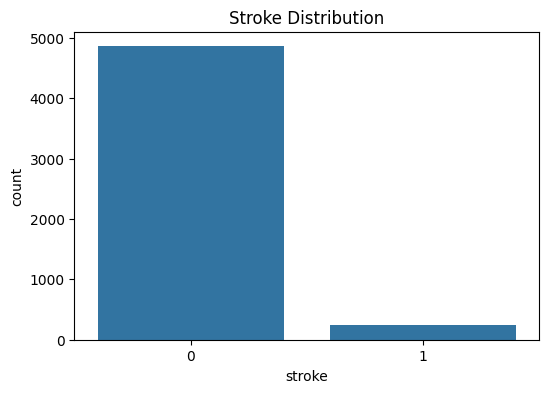

In [ ]:
# plot distribution of stroke variable
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=stroke_data)
plt.title("Stroke Distribution")
plt.show()

Observation: Most samples belong to no stroke class..

This shows that dataset is highly imbalanced

it may have bias toward majoirty class that is no stroke

---


Age Distribution

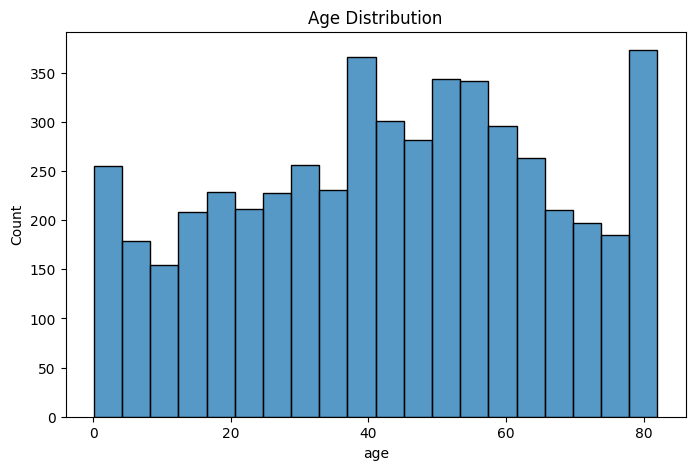

In [ ]:
# plot age distribution
plt.figure(figsize=(8,5))
sns.histplot(stroke_data['age'])
plt.title('Age Distribution')
plt.show()

Observation:
Dataset contains various age groups, and some more around like from 40 to 80.. compared to 1-40.

Stroke vs Age

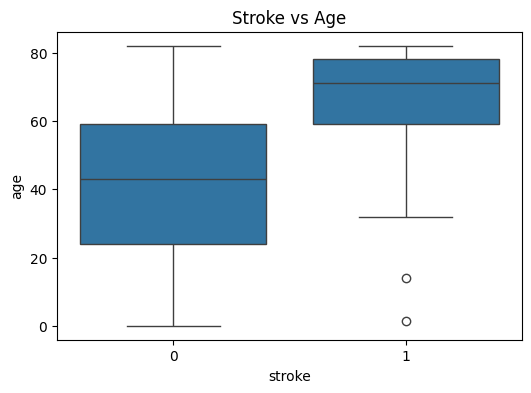

In [ ]:
# plot stroke versus age
plt.figure(figsize=(6,4))
sns.boxplot(x='stroke', y='age', data=stroke_data)
plt.title("Stroke vs Age")
plt.show()

People with stroke belong age gourp 60-80(old age groups) and wihtout stroke from ages around 20-60 (young and middle aged).

Age may be important factor.

Stroke vs Hypertension

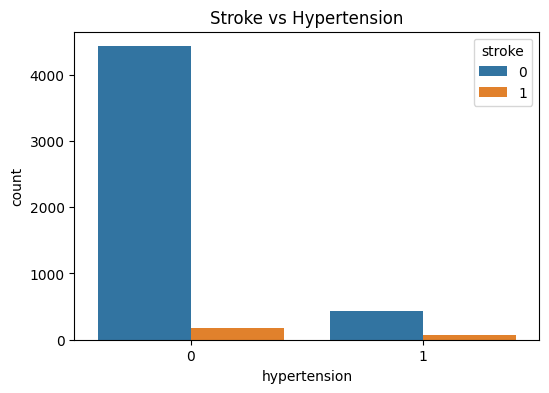

In [ ]:
# plot stroke versus hypertension
plt.figure(figsize=(6,4))
sns.countplot(x='hypertension', hue='stroke', data=stroke_data)
plt.title("Stroke vs Hypertension")
plt.show()

Patients with hypertension - have higher proportion of stroke cases compared to patients with no hypertension.



heartdisease vs stroke

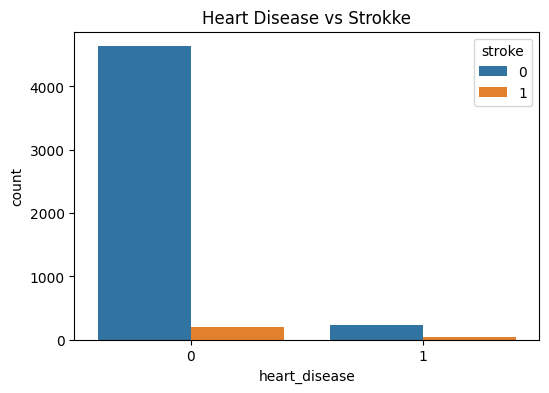

In [ ]:
# plot heart disease versus stroke
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease',hue='stroke',data=stroke_data)
plt.title("Heart Disease vs Strokke")
plt.show()

This is also same like hypertension. Heart Disease may increase the chance of stroke

with heart_disease - more stroke cases compared to

Without heart_disese - less stroke cases (relatively)

BMI vs Stroke

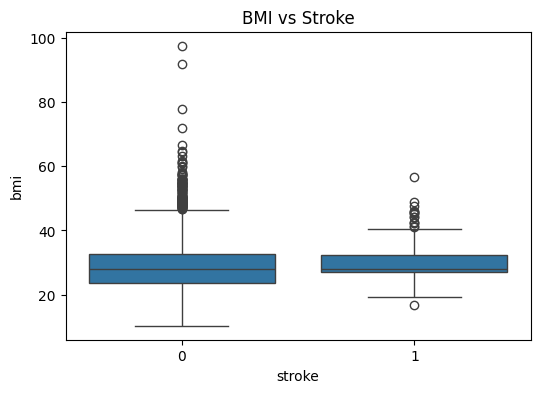

In [ ]:
# plot bmi versus stroke
plt.figure(figsize=(6,4))
sns.boxplot(x='stroke',y='bmi',data=stroke_data)
plt.title('BMI vs Stroke')
plt.show()

BMI values both classes(stroke and non-stroke) are of almost same, no difference

Smoking Status vs Stroke

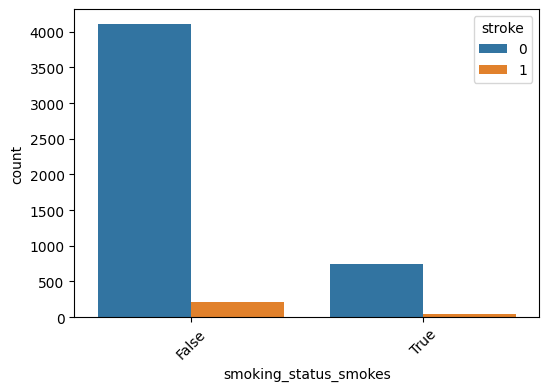

In [ ]:
# plot smoking status versus stroke
plt.figure(figsize=(6,4))
sns.countplot(x='smoking_status_smokes',hue='stroke',data=stroke_data)
plt.xticks(rotation=45)
plt.show()

Stroke class cases are being seen in both smoker and non smokers.

Smoking may influence stroke risk, but according to our data no strong diff between them.

Gender vs Stroke

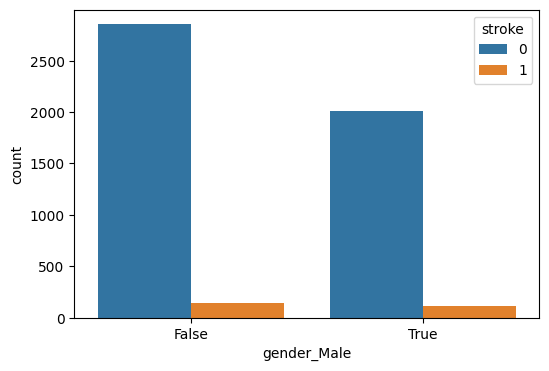

In [ ]:
# plot gender versus stroke
plt.figure(figsize=(6,4))
sns.countplot(x='gender_Male',hue='stroke',data=stroke_data)
plt.show()

No big difference in gender for female and male. Ii iss simolar for both ...

Correlation Heat Map


---


*   To find important features




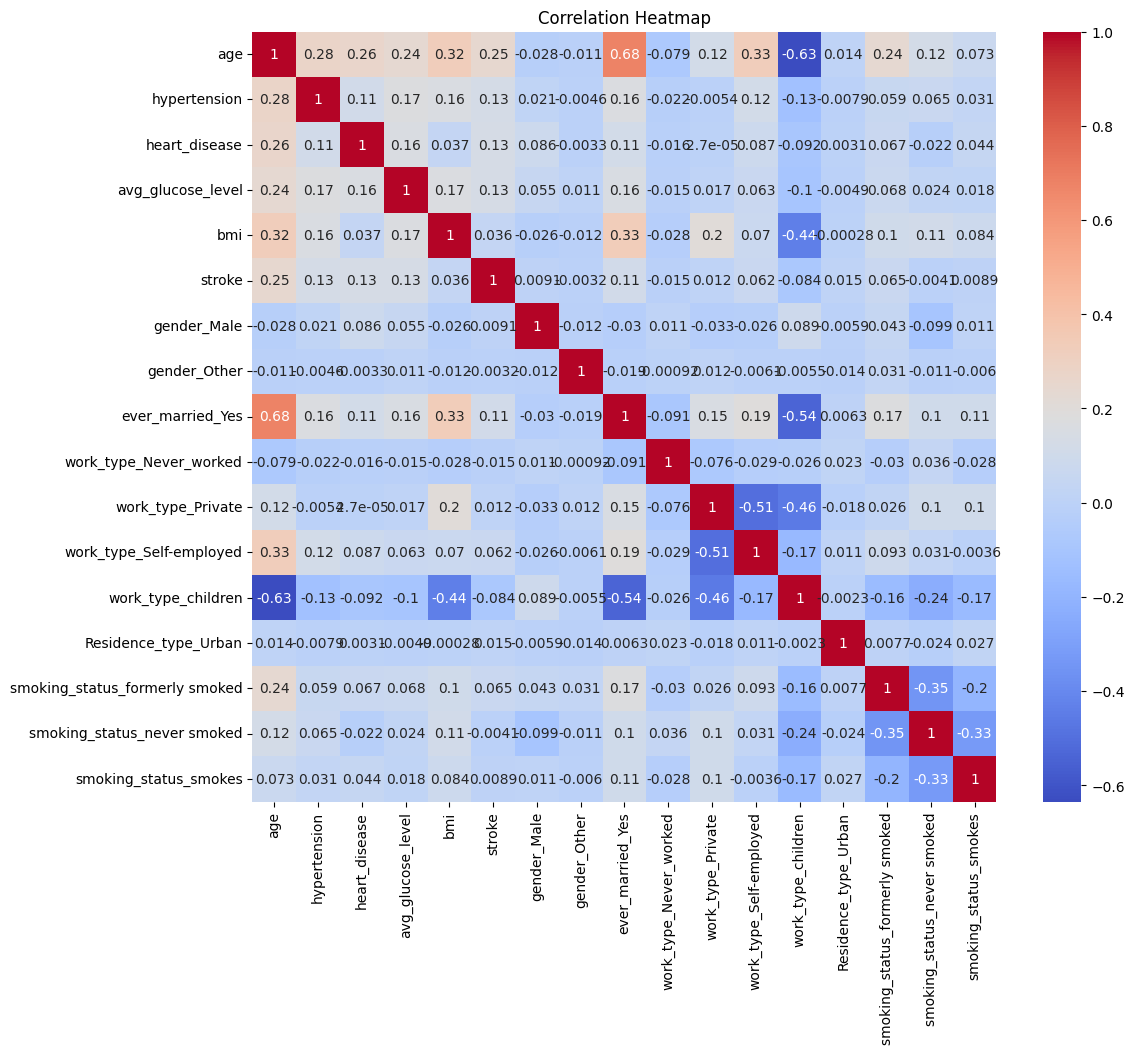

In [ ]:
# plot correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(stroke_data.corr(), annot = True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Observation on HeatMap

Age, hypertension, heart disease and avg glucose level have a +ve -- may be useful

Remaing other variables -- showing weak relations with stroke like gender, smoking

#Model Training

In [ ]:
# split data into X and y
X = stroke_data.drop('stroke', axis=1)   #features(inputs)
y = stroke_data['stroke']   #target variable(output we are going to predict)

In [ ]:
X.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,False,False,True,False,False,True,False,False,False,True,False


In [ ]:
# split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   #80% train, 20% test
    random_state=42  # fixed randomness , same results foe evry time we runn.
)

Feature Scaling

In [ ]:
# scale the features of data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaling is applied bcz these models like Lgistic regression and SVM performs better when features are on similar scales

Logistic Regression Model with default parameters

In [ ]:
# train logistic regression model
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
# evaluate logistic regression model
print("evaluation of Logistic regression model: \n")

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {lr_accuracy}")    # overall correct

lr_precision = precision_score(y_test, y_pred_lr)
print(f"Precision: {lr_precision}")   #among predicted stroke, how many actually stroke

lr_recall = recall_score(y_test, y_pred_lr)
print(f"Recall: {lr_recall}")  #among actual stroke, how many detected

lr_f1 = f1_score(y_test, y_pred_lr)
print(f"F1_Score: {lr_f1}")  #balance of both precision and recall

evaluation of Logistic regression model: 

Accuracy: 0.9393346379647749
Precision: 0.0
Recall: 0.0
F1_Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Even though the accuracy is very high (0.94) the recall is very low (0.0). THis shows model fails to identify most actual steoke patients due to dataset imbalnce. We need to improve minority class (stroke)

SVM

In [ ]:
# train support vector machine model
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [ ]:
# evaluate svm model
print("evaluation of SVM (SVC) model: \n")

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: svvm_{svm_accuracy}")    # overall correct

svm_precision = precision_score(y_test, y_pred_svm)
print(f"Precision: {svm_precision}")   #among predicted stroke, how many actually stroke

svm_recall = recall_score(y_test, y_pred_svm)
print(f"Recall: {svm_recall}")  #among actual stroke, how many detected

svm_f1 = f1_score(y_test, y_pred_svm)
print(f"F1_Score: {svm_f1}")  #balance of both precision and recall

evaluation of SVM (SVC) model: 

Accuracy: svvm_0.9393346379647749
Precision: 0.0
Recall: 0.0
F1_Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dataset is highly imablanced anf svm mostly predict everything

Decision Tree

In [ ]:
# train decision tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled,y_train)
y_pred_dt=dt.predict(X_test_scaled)

In [ ]:
# evaluate decision tree model
print("evaluation of Decisiont Tree model: \n")

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {dt_accuracy}")    # overall correct

dt_precision = precision_score(y_test, y_pred_dt)
print(f"Precision: {dt_precision}")   #among predicted stroke, how many actually stroke

dt_recall = recall_score(y_test, y_pred_dt)
print(f"Recall: {dt_recall}")  #among actual stroke, how many detected

dt_f1 = f1_score(y_test, y_pred_dt)
print(f"F1_Score: {dt_f1}")  #balance of both precision and recal

evaluation of Decisiont Tree model: 

Accuracy: 0.910958904109589
Precision: 0.24561403508771928
Recall: 0.22580645161290322
F1_Score: 0.23529411764705882


Random FOresttt

In [ ]:
# train random forest model
rf = RandomForestClassifier(random_state=42)  #fixed randomness, same result on every runn
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
# evaluate random forest model
print("evaluation of RF model: \n")

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {rf_accuracy}")    # overall correct

rf_precision = precision_score(y_test, y_pred_rf)
print(f"Precision: {rf_precision}")   #among predicted stroke, how many actually stroke

rf_recall = recall_score(y_test, y_pred_rf)
print(f"Recall: {rf_recall}")  #among actual stroke, how many detected

rf_f1 = f1_score(y_test, y_pred_rf)
print(f"F1_Score: {rf_f1}")  #balance of both precision and recal

evaluation of RF model: 

Accuracy: 0.9393346379647749
Precision: 0.0
Recall: 0.0
F1_Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


XG BOOSt

In [ ]:
# train xgboost model
xgb = XGBClassifier(random_state = 42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

In [ ]:
# evaluate xgboost model
print("evaluation of XGB model: \n")

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {xgb_accuracy}")    # overall correct

xgb_precision = precision_score(y_test, y_pred_xgb)
print(f"Precision: {xgb_precision}")   #among predicted stroke, how many actually stroke

xgb_recall = recall_score(y_test, y_pred_xgb)
print(f"Recall: {xgb_recall}")  #among actual stroke, how many detected

xgb_f1 = f1_score(y_test, y_pred_xgb)
print(f"F1_Score: {xgb_f1}")  #balance of both precision and recall

evaluation of XGB model: 

Accuracy: 0.9373776908023483
Precision: 0.42857142857142855
Recall: 0.0967741935483871
F1_Score: 0.15789473684210525


In [ ]:
# compare all trained models
print("Model\t\tAccuracy\tRecall\t\tF1")

print("LR\t\t",
      round(lr_accuracy,3),
      "\t\t",
      round(lr_recall,3),
      "\t\t",
      round(lr_f1,3))



print("DT\t\t",
      round(dt_accuracy,3),
      "\t\t",
      round(dt_recall,3),
      "\t\t",
      round(dt_f1,3))

print("RF\t\t",
      round(rf_accuracy,3),
      "\t\t",
      round(rf_recall,3),
      "\t\t",
      round(rf_f1,3))

print("SVM\t\t",
      round(svm_accuracy,3),
      "\t\t",
      round(svm_recall,3),
      "\t\t",
      round(svm_f1,3))

print("XGB\t\t",
      round(xgb_accuracy,3),
      "\t\t",
      round(xgb_recall,3),
      "\t\t",
      round(xgb_f1,3))

Model		Accuracy	Recall		F1
LR		 0.939 		 0.0 		 0.0
DT		 0.911 		 0.226 		 0.235
RF		 0.939 		 0.0 		 0.0
SVM		 0.939 		 0.0 		 0.0
XGB		 0.937 		 0.097 		 0.158


# Choosing DT

So for healthcare related problems ,,
the recall should be higher because there can't be missing strokes

(if stroke is detected even with no sroke-- no problem just checking it may not be risky)

(if stroke is not detected - then it may be highly riskyy)

, no use of accuracy here
so here we are choosing DT because it has the highest recall valueeeee and also f1  -- in identifying stroke cases

Aply SMOTE for balancing

In [ ]:
# apply smote for oversampling
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_smote,y_smote = sm.fit_resample(X,y)


In [ ]:
# split smoted data into train test
X_train_smote,X_test_smote,y_train_smote,y_test_smote = train_test_split(X_smote,
                                                 y_smote,
                                                 test_size = 0.2,
                                                 random_state = 42
                                                 )

In [ ]:
print("Before SMOTE:", y_train.value_counts())

print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: stroke
0    3901
1     187
Name: count, dtype: int64
After SMOTE: stroke
1    3891
0    3886
Name: count, dtype: int64


DT with Balanced data

In [ ]:
# train decision tree on smoted data
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train_smote,y_train_smote)
y_pred_dt2 = dt2.predict(X_test_smote)

In [ ]:
# evaluate decision tree on smoted data
print("evaluation of Decisiont Tree 2 model: \n")

dt2_accuracy = accuracy_score(y_test_smote, y_pred_dt2)
print(f"Accuracy: {dt2_accuracy}")    # overall correct

dt2_precision = precision_score(y_test_smote, y_pred_dt2)
print(f"Precision: {dt2_precision}")   #among predicted stroke, how many actually stroke

dt2_recall = recall_score(y_test_smote, y_pred_dt2)
print(f"Recall: {dt2_recall}")  #among actual stroke, how many detected

dt2_f1 = f1_score(y_test_smote, y_pred_dt2)
print(f"F1_Score: {dt2_f1}")  #balance of both precision and recal

evaluation of Decisiont Tree 2 model: 

Accuracy: 0.9218508997429306
Precision: 0.9106425702811245
Recall: 0.9350515463917526
F1_Score: 0.9226856561546287


In [ ]:
print(
"Model\t\tAccuracy\tPrecision\tRecall\t\tF1"
)

print(
f"Before SMOTE\t{dt_accuracy:.2f}\t\t{dt_precision:.2f}\t\t{dt_recall:.2f}\t\t{dt_f1:.2f}"
)

print(
f"SMotE \t\t{dt2_accuracy:.2f}\t\t{dt2_precision:.2f}\t\t{dt2_recall:.2f}\t\t{dt2_f1:.2f}"
)

Model		Accuracy	Precision	Recall		F1
Before SMOTE	0.91		0.25		0.23		0.24
SMotE 		0.92		0.91		0.94		0.92


Here Precision, Recall, and F1 score all increased by a huge value.. so after smoting the model will be better

Feature Selection

In [ ]:
# feature selection using selectkbest

selector = SelectKBest(score_func=f_classif, k=10)  #f_classif bcz for of classification,, relation with target class..

X_train_selected = selector.fit_transform(X_train_smote,y_train_smote)
X_test_selected = selector.transform(X_test_smote)

In [ ]:
selected_features = X_train_smote.columns[selector.get_support()]

print(selected_features)

Index(['age', 'avg_glucose_level', 'gender_Male', 'ever_married_Yes',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked'],
      dtype='object')


DT with balanced data after Feature Selectionn

In [ ]:
# train DT+SMOTE after feature selection

dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X_train_selected,y_train_smote)
y_pred_dt3 = dt3.predict(X_test_selected)

In [ ]:
# evaluate decision tree on smoted and feature selection data
print("evaluation of Decisiont Tree 3 model: \n")

dt3_accuracy = accuracy_score(y_test_smote, y_pred_dt3)
print(f"Accuracy: {dt3_accuracy}")    # overall correct

dt3_precision = precision_score(y_test_smote, y_pred_dt3)
print(f"Precision: {dt3_precision}")   #among predicted stroke, how many actually stroke

dt3_recall = recall_score(y_test_smote, y_pred_dt3)
print(f"Recall: {dt3_recall}")  #among actual stroke, how many detected

dt3_f1 = f1_score(y_test_smote, y_pred_dt3)
print(f"F1_Score: {dt3_f1}")  #balance of both precision and recal

evaluation of Decisiont Tree 3 model: 

Accuracy: 0.9167095115681234
Precision: 0.9089068825910931
Recall: 0.9257731958762887
F1_Score: 0.9172625127681308


In [ ]:
print(
"Model\t\tAccuracy\tPrecision\tRecall\t\tF1"
)

print(
f"DT + SMOTE\t{dt2_accuracy:.2f}\t\t{dt2_precision:.2f}\t\t{dt2_recall:.2f}\t\t{dt2_f1:.2f}"
)

print(
f"DT+ FS \t\t{dt3_accuracy:.2f}\t\t{dt3_precision:.2f}\t\t{dt3_recall:.2f}\t\t{dt3_f1:.2f}"
)

Model		Accuracy	Precision	Recall		F1
DT + SMOTE	0.92		0.91		0.94		0.92
DT+ FS 		0.92		0.91		0.93		0.92


No much improvement comparing after feature selection

Hyperparameter Tuning using GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2,5,10],
    'criterion': ['gini','entropy']
    }

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='recall'
    )

grid.fit(X_train_selected,y_train_smote)

print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}


Regularization was applied by limiting max_depth and increasing min_samples_split. This prevents overly complex trees and reduces overfitting, improving model generalization.

---
GridSearchCV selected entropy, unlimited tree depth and minimum split size of 2 as optimal parameters. These settings improved the model's ability to capture complex patterns in stroke prediction.

DT after hyperparameter tuning

In [ ]:
#dt4 is after tuning

dt4 = grid.best_estimator_

y_pred_dt4 = dt4.predict(X_test_selected)

In [ ]:
print("evaluation after tuning:\n")

dt4_accuracy = accuracy_score(y_test_smote,y_pred_dt4)
print("Accuracy:",dt4_accuracy)

dt4_precision =precision_score(y_test_smote,y_pred_dt4)
print("Precision:",dt4_precision)

dt4_recall =recall_score(y_test_smote,y_pred_dt4)
print("Recall:",dt4_recall)


dt4_f1 =f1_score(y_test_smote,y_pred_dt4)

print("F1:",dt4_f1)

evaluation after tuning:

Accuracy: 0.922879177377892
Precision: 0.9218106995884774
Recall: 0.9237113402061856
F1: 0.9227600411946447


In [ ]:
print(
"Model\t\tAccuracy\tPrecision\tRecall\t\tF1"
)

print(
f"DT+SMOTE\t{dt2_accuracy:.2f}\t\t{dt2_precision:.2f}\t\t{dt2_recall:.2f}\t\t{dt2_f1:.2f}"
)

print(
f"DT+FS\t\t{dt3_accuracy:.2f}\t\t{dt3_precision:.2f}\t\t{dt3_recall:.2f}\t\t{dt3_f1:.2f}"
)

print(
f"DT+Tuned\t{dt4_accuracy:.2f}\t\t{dt4_precision:.2f}\t\t{dt4_recall:.2f}\t\t{dt4_f1:.2f}"
)

Model		Accuracy	Precision	Recall		F1
DT+SMOTE	0.92		0.91		0.94		0.92
DT+FS		0.92		0.91		0.93		0.92
DT+Tuned	0.92		0.92		0.92		0.92


Even after feature selection an hyperparamater tuning there is no much imporvement in themm

so here are we are selecting the best model as dt2(DT after SMOTE) because it has highest recall compared to others

Confusion Matrixx

Confusion Matrix for Decision Tree + SMOTE:

[[886  89]
 [ 63 907]]


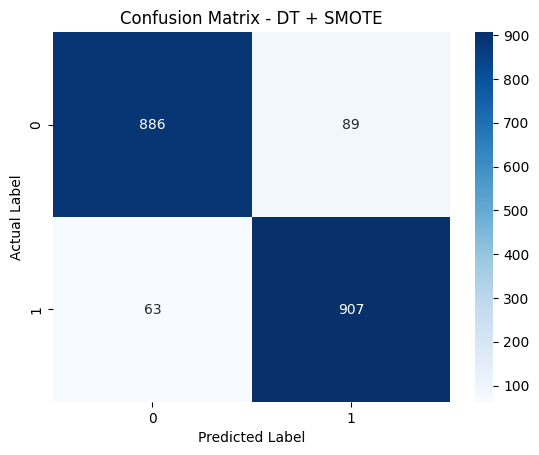

In [ ]:
# confusion matrix for best model (DT + SMOTE)

print("Confusion Matrix for Decision Tree + SMOTE:\n")
cm = confusion_matrix(y_test_smote,y_pred_dt2)
print(cm)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - DT + SMOTE')

plt.show()

### Observation

The confusion matrix shows that the model correctly identified most stroke and non-stroke cases, with fewer false negative(stroke but predicted no stroke). This resulted in high recall, making the model effective for stroke prediction.

Feeture Importance

In [ ]:
# feature importance for best model

importance = dt2.feature_importances_

feature_names = X.columns

for name, score in zip(feature_names,importance):
    print(name,":",round(score,3))

age : 0.478
hypertension : 0.008
heart_disease : 0.015
avg_glucose_level : 0.143
bmi : 0.093
gender_Male : 0.037
gender_Other : 0.0
ever_married_Yes : 0.007
work_type_Never_worked : 0.0
work_type_Private : 0.043
work_type_Self-employed : 0.042
work_type_children : 0.006
Residence_type_Urban : 0.027
smoking_status_formerly smoked : 0.03
smoking_status_never smoked : 0.036
smoking_status_smokes : 0.035


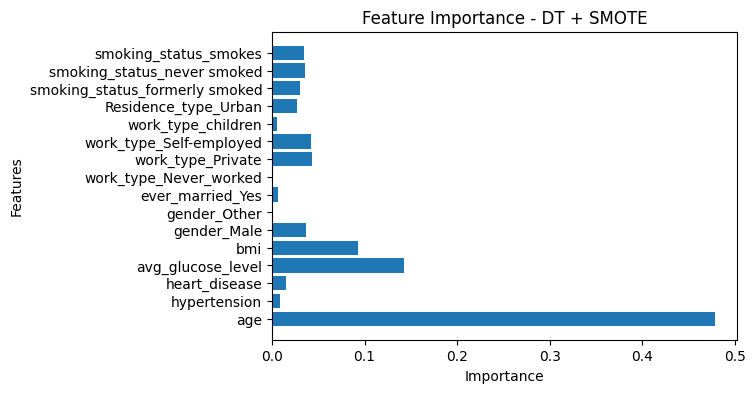

In [ ]:
importance =dt2.feature_importances_
feature_names =X.columns

plt.figure(figsize=(6,4))
plt.barh(feature_names,importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - DT + SMOTE")
plt.show()

### Observation

The feature importance graph shows that age was the most influential feature for predicting stroke, followed by average glucose level and BMI. Features related to smoking, work type and gender had lower contribution to model prediction.

Final Comparison

In [ ]:
print(
"Model\t\t\tAccuracy\tPrecision\tRecall\t\tF1"
)

print(
f"LR\t\t\t{lr_accuracy:.2f}\t\t{lr_precision:.2f}\t\t{lr_recall:.2f}\t\t{lr_f1:.2f}"
)

print(
f"SVM\t\t\t{svm_accuracy:.2f}\t\t{svm_precision:.2f}\t\t{svm_recall:.2f}\t\t{svm_f1:.2f}"
)

print(
f"DT\t\t\t{dt_accuracy:.2f}\t\t{dt_precision:.2f}\t\t{dt_recall:.2f}\t\t{dt_f1:.2f}"
)

print(
f"RF\t\t\t{rf_accuracy:.2f}\t\t{rf_precision:.2f}\t\t{rf_recall:.2f}\t\t{rf_f1:.2f}"
)

print(
f"DT+SMOTE\t\t{dt2_accuracy:.2f}\t\t{dt2_precision:.2f}\t\t{dt2_recall:.2f}\t\t{dt2_f1:.2f}"
)

print(
f"DT+SMOTE+FS\t\t{dt3_accuracy:.2f}\t\t{dt3_precision:.2f}\t\t{dt3_recall:.2f}\t\t{dt3_f1:.2f}"
)

print(
f"DT+Tuned\t\t{best_accuracy:.2f}\t\t{best_precision:.2f}\t\t{best_recall:.2f}\t\t{best_f1:.2f}"
)

Model			Accuracy	Precision	Recall		F1
LR			0.94		0.00		0.00		0.00
SVM			0.94		0.00		0.00		0.00
DT			0.91		0.25		0.23		0.24
RF			0.94		0.00		0.00		0.00
DT+SMOTE		0.92		0.91		0.94		0.92
DT+SMOTE+FS		0.92		0.91		0.93		0.92
DT+Tuned		0.92		0.92		0.92		0.92


Among baseline models, Decision Tree performed better in detecting stroke cases compared to Logistic Regression, SVM and Random Forest.
Eevn with high accuracy there is low recall.

Applying SMOTE significantly improved recall from baseline performance. Feature selection and hyperparameter tuning maintained similar performance, but Decision Tree with SMOTE achieved the highest recall (0.94), making it the final selected model for stroke prediction.

FInal MOdel Savingg

In [ ]:
# save final model using pickle

import pickle

filename = 'stroke_prediction_model.sav'
pickle.dump(dt2,open(filename,'wb'))
print("Model saved successfully")

Model saved successfully


In [ ]:
# load saved model

load_model = pickle.load(open(filename,'rb'))
model_score =load_model.score(X_test_smote,y_test_smote)
print(model_score)

0.9218508997429306


# Conclusion

In this project, stroke prediction was done using a healthcare dataset. Data preprocessing and exploratory data analysis helped identify important patterns, where age, glucose level and BMI showed stronger relation with stroke.

Multiple baseline models including Logistic Regression, SVM, Decision Tree and Random Forest were trained and compared. Among them, Decision Tree showed better performance in identifying stroke cases.

Since the dataset was imbalanced, SMOTE was applied to improve minority class prediction. After applying SMOTE, the recall and F1-score improved, making the model better at predicting actual stroke cases.

Feature selection and hyperparameter tuning were also performed to improve model performance. However, Decision Tree with SMOTE given the best balance between precision, recall and F1-score.

The final selected model was Decision Tree + SMOTE with approximately 92% accuracy and 94% recall. The model was saved using pickle.

Thus, the project shows that handling class imbalance and model improvement techniques can improve healthcare prediction performance.